In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import random
import tensorflow as tf
from src.NN_Utils import TimeSeriesRandomSearch, make_build_model
from src.Utils import plot_performance_analysis
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score

**Sección para Asegurar la Reproducibilidad**

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

<h2>Lectura y Tratamiento de Datos</h2>

In [3]:
X = pd.read_csv('../dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
y_columns = [f'V{i}' for i in range(2,15)] + ['PERD', 'QGEN7'] #V1 ES SIEMPRE 1.0 EN DATASET
Y = pd.read_csv('../dataset/dataset_out.txt', index_col=0).loc[:, y_columns]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]

**Validación por Retención (Tratamiento como Serie Temporal)**

In [4]:
# VALIDACIÓN POR RETENCIÓN PARA EVALUACIÓN FINAL DEL MEJOR MODELO
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

<h2>Búsqueda de Mejores Modelos</h2>

In [5]:
input_dim = x_train.shape[1]
num_volts = len([c for c in y_train.columns if c.startswith('V')])
builder_function = make_build_model(input_dim, num_volts)

y_train_qgen = y_train[['QGEN7']]
y_train_perd = y_train[['PERD']]
y_train_volt = y_train.drop(columns=['QGEN7', 'PERD'])

tuner = TimeSeriesRandomSearch(builder_function, objective='val_loss', max_trials=10, overwrite=True, project_name='nn_random_search', seed=42)

In [6]:
tuner.search(
    x_train,
    y={
        'out_volt': y_train_volt,
        'out_perd': y_train_perd,
        'out_qgen7': y_train_qgen,
    },
    epochs=10,
    batch_size=32
)

Trial 10 Complete [00h 03m 10s]
val_loss: 0.01295625902712345

Best val_loss So Far: 0.011893408931791782
Total elapsed time: 00h 21m 24s


In [7]:
best_random_model = tuner.oracle.get_best_trials(1)[0]
for metric_name in best_random_model.metrics.metrics.keys():
    val = best_random_model.metrics.get_best_value(metric_name)
    print(f"{metric_name}: {val:.5f}")

val_loss: 0.01189
val_out_perd_loss: 0.00033
val_out_perd_mae: 0.01199
val_out_perd_mape: 6.31971
val_out_perd_r2_score: 0.98438
val_out_qgen7_loss: 0.01057
val_out_qgen7_mae: 0.06485
val_out_qgen7_mape: 11.33926
val_out_qgen7_r2_score: 0.72674
val_out_volt_loss: 0.00067
val_out_volt_mae: 0.01985
val_out_volt_mape: 137.14494
val_out_volt_r2_score: 0.96849


<h2>Evaluación del Mejor Modelo</h2>

In [8]:
best_random_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = builder_function(best_random_hp)

normalizer_x = MinMaxScaler(feature_range=(0, 1))
x_train_norm = normalizer_x.fit_transform(x_train)
x_test_norm = normalizer_x.transform(x_test)
normalizer_qgen = MinMaxScaler(feature_range=(0, 1))
normalizer_volts = MinMaxScaler(feature_range=(0, 1))
normalizer_perd = MinMaxScaler(feature_range=(0, 1))
y_train_qgen_norm = normalizer_qgen.fit_transform(y_train_qgen)
y_train_perd_norm = normalizer_perd.fit_transform(y_train_perd)
y_train_volt_norm = normalizer_volts.fit_transform(y_train_volt)

In [9]:
results = best_model.fit(
    x_train_norm,
    {
        'out_qgen7': y_train_qgen_norm,
        'out_volt': y_train_volt_norm,
        'out_perd': y_train_perd_norm
    },
    epochs=20,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/20
2230/2230 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0253 - out_perd_loss: 8.0681e-04 - out_perd_mae: 0.0170 - out_perd_mape: 735.7674 - out_perd_r2_score: 0.8935 - out_qgen7_loss: 0.0168 - out_qgen7_mae: 0.0878 - out_qgen7_mape: 11567.9287 - out_qgen7_r2_score: 0.5647 - out_volt_loss: 0.0069 - out_volt_mae: 0.0491 - out_volt_mape: 2462.0847 - out_volt_r2_score: 0.5666 - val_loss: 0.0148 - val_out_perd_loss: 1.7947e-04 - val_out_perd_mae: 0.0096 - val_out_perd_mape: 9.6816 - val_out_perd_r2_score: 0.9765 - val_out_qgen7_loss: 0.0137 - val_out_qgen7_mae: 0.0757 - val_out_qgen7_mape: 13.3310 - val_out_qgen7_r2_score: 0.6456 - val_out_volt_loss: 6.8204e-04 - val_out_volt_mae: 0.0202 - val_out_volt_mape: 3.8018 - val_out_volt_r2_score: 0.9579
Epoch 2/20
2230/2230 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0163 - out_perd_loss: 3.1130e-04 - out_perd_mae: 0.0131 - out_perd_mape: 404.9804 - out_perd_r2_score: 0.9589 - out_qgen7_loss: 0.0150 - out_qgen7_mae: 0.0818 - out_qgen7_mape:

In [10]:
predictions = best_model.predict(x_test_norm)
pred_volts_norm = predictions[0]
pred_perd_norm = predictions[1]
pred_qgen_norm = predictions[2]
y_pred_volts = normalizer_volts.inverse_transform(pred_volts_norm)
y_pred_perd = normalizer_perd.inverse_transform(pred_perd_norm)
y_pred_qgen = normalizer_qgen.inverse_transform(pred_qgen_norm)
y_pred = pd.DataFrame(np.hstack([y_pred_volts, y_pred_perd, y_pred_qgen]), columns=y_test.columns, index=y_test.index)

656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step


In [11]:
evaluate_MAE = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
evaluate_MAPE = mean_absolute_percentage_error(y_test, y_pred, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
evaluate_MAPE_shifted = mean_absolute_percentage_error(y_test + 1.0, y_pred + 1.0, multioutput='raw_values')
evaluate_R2 = r2_score(y_test, y_pred, multioutput='raw_values')

In [12]:
# RESULTADOS CON MAPE DESPLAZADO
evaluate_data_score_shifted = np.vstack([evaluate_MAE, evaluate_MAPE_shifted, evaluate_R2])
evaluations_shifted = pd.DataFrame(evaluate_data_score_shifted, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations_shifted

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001750,0.001746,0.001793,0.001790,0.001756,0.001751,0.001785,0.001776,0.001810,0.001850,0.001752,0.001357,0.001423,0.128734,0.009333
MAPE,0.000887,0.000885,0.000909,0.000908,0.000891,0.000888,0.000905,0.000901,0.000918,0.000938,0.000889,0.000685,0.000719,0.014942,0.008839
R2,0.972870,0.973232,0.972248,0.972418,0.973223,0.973335,0.972525,0.972752,0.971908,0.970836,0.973349,0.979080,0.977363,0.983239,0.838093


In [13]:
# RESULTADOS SIN DESPLAZADO
evaluate_data_score = np.vstack([evaluate_MAE, evaluate_MAPE, evaluate_R2])
evaluations = pd.DataFrame(evaluate_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001750,0.001746,0.001793,0.001790,0.001756,0.001751,0.001785,0.001776,0.001810,0.001850,0.001752,0.001357,0.001423,0.128734,9.332742e-03
MAPE,0.001798,0.001796,0.001846,0.001843,0.001807,0.001803,0.001837,0.001828,0.001864,0.001905,0.001803,0.001384,0.001452,0.017664,1.766997e+13
R2,0.972870,0.973232,0.972248,0.972418,0.973223,0.973335,0.972525,0.972752,0.971908,0.970836,0.973349,0.979080,0.977363,0.983239,8.380935e-01


In [14]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE DESPLAZADO)
volts_columns = [c for c in y_train.columns if c.startswith('V')]
pd.DataFrame({
    'Voltajes (Desplazados)': evaluations_shifted[volts_columns].mean(axis=1),
    'Pérdidas (Desplazada)': evaluations_shifted['PERD'],
    'Potencia Reactiva (Desplazada)': evaluations_shifted['QGEN7']
})

,Voltajes (Desplazados),Pérdidas (Desplazada),Potencia Reactiva (Desplazada)
MAE,0.001718,0.128734,0.009333
MAPE,0.000871,0.014942,0.008839
R2,0.973472,0.983239,0.838093


In [15]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE SIN DESPLAZAMIENTO)
pd.DataFrame({
    'Voltajes': evaluations[volts_columns].mean(axis=1),
    'Pérdidas': evaluations['PERD'],
    'Potencia Reactiva': evaluations['QGEN7']
})

,Voltajes,Pérdidas,Potencia Reactiva
MAE,0.001718,0.128734,9.332742e-03
MAPE,0.001767,0.017664,1.766997e+13
R2,0.973472,0.983239,8.380935e-01


<h2>Figuras de Rendimiento del Mejor Modelo</h2>

In [16]:
best_model.save('../models/MO_NeuralNetwork.keras')

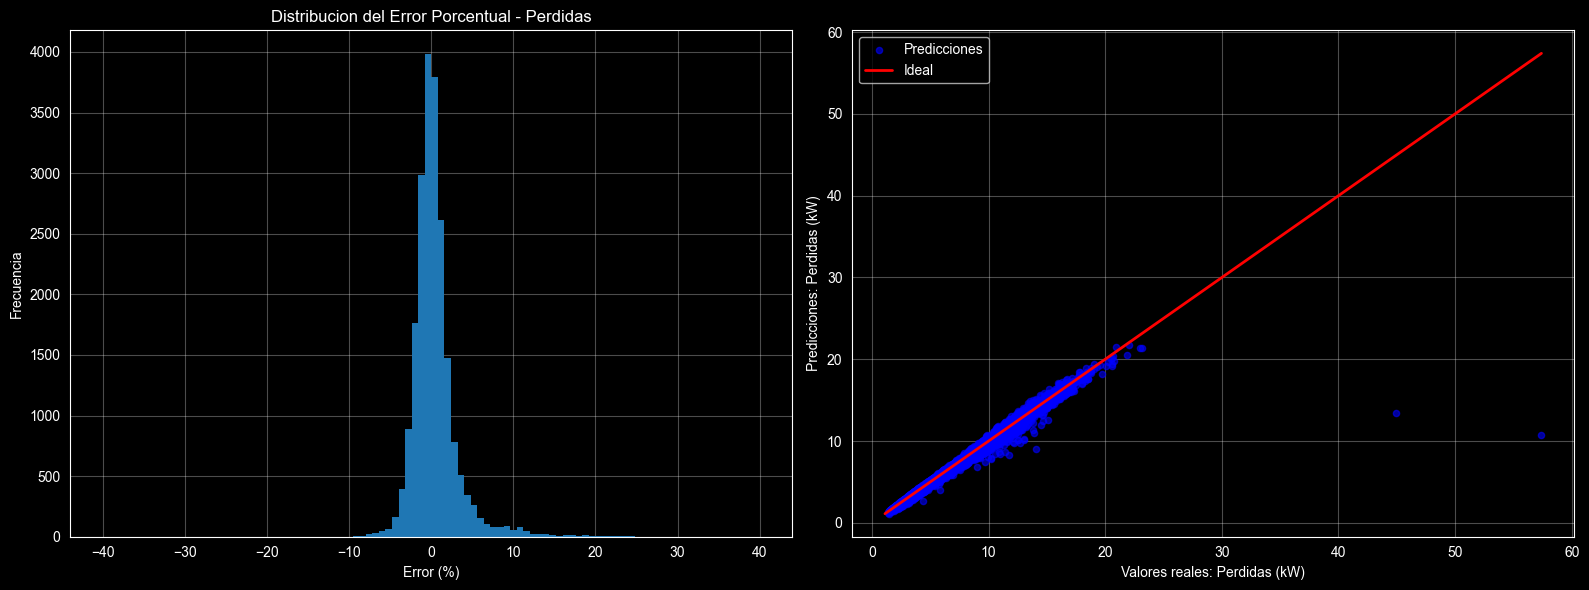

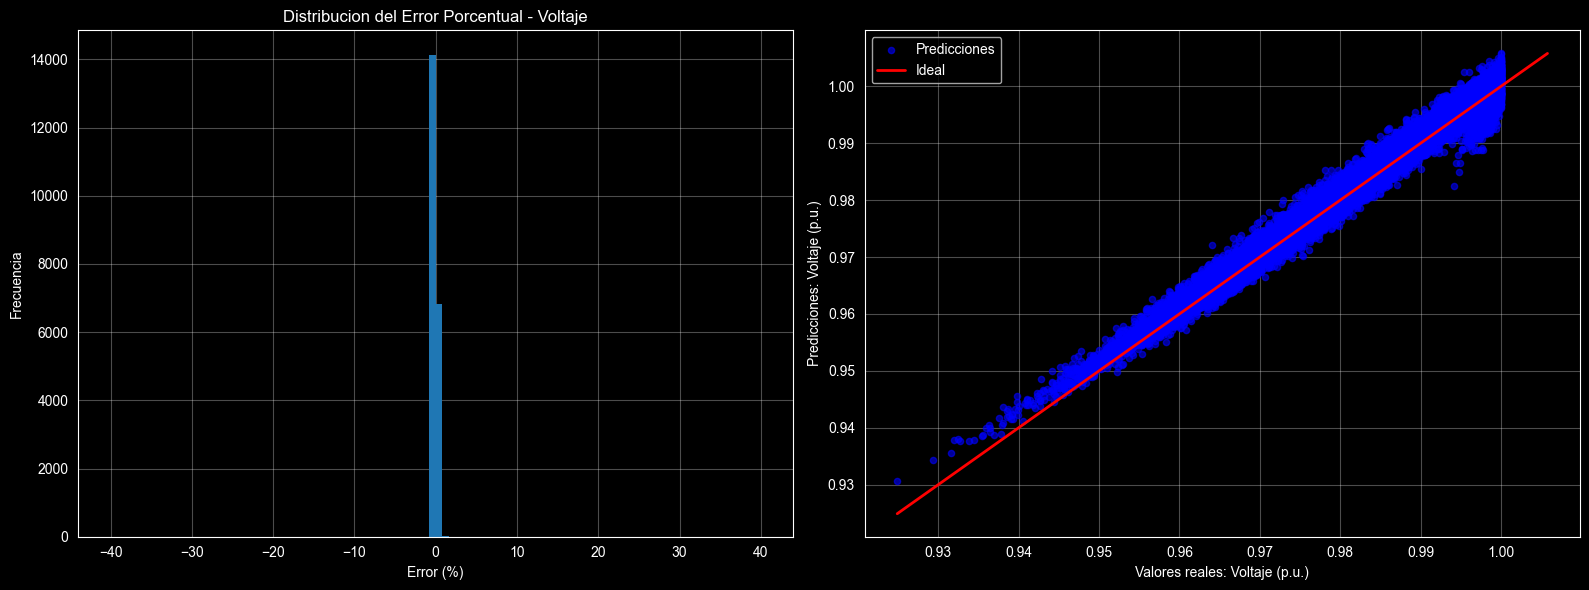

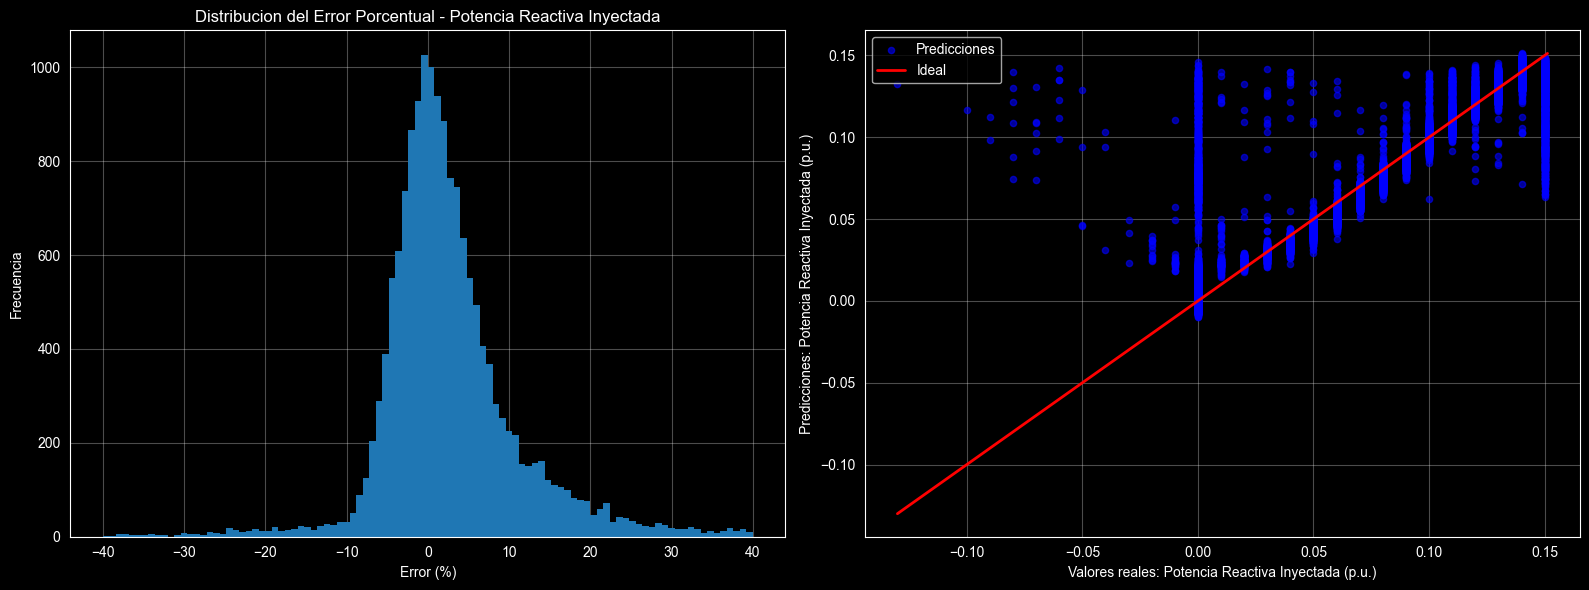

In [17]:
plot_performance_analysis(
    y_test['PERD'],
    y_pred.iloc[:, -2],
    variable_name="Perdidas",
    unit_label="kW",
    path='../figures/NeuralNetwork/MO_NeuralNetwork_Perd.png'
)
plot_performance_analysis(
    y_test['V13'],
    y_pred.loc[:, 'V13'],
    variable_name="Voltaje",
    unit_label="p.u.",
    path='../figures/NeuralNetwork/MO_NeuralNetwork_V13.png'
)
plot_performance_analysis(
    y_test['QGEN7'],
    y_pred.iloc[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u.",
    path='../figures/NeuralNetwork/MO_NeuralNetwork_QGen.png'
)